In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Epileptic Seizure Recognition.csv.zip to Epileptic Seizure Recognition.csv (2).zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Epileptic Seizure Recognition.csv to Epileptic Seizure Recognition.csv


In [ ]:
import pandas as pd

data = pd.read_csv("Epileptic Seizure Recognition.csv")

data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [ ]:
data = data.drop('Unnamed: 0', axis=1)

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
print(data.columns)

Index(['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=180)


In [ ]:
data = data.drop(columns=['Unnamed: 0'], errors='ignore')

In [ ]:
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [ ]:
data['y'] = data['y'].apply(lambda x: 1 if x == 1 else 0)

In [ ]:
X = data.drop('y', axis=1)
y = data['y']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: 'X21.V1.791'

In [ ]:
print(data.dtypes)

Unnamed    object
X1          int64
X2          int64
X3          int64
X4          int64
            ...  
X175        int64
X176        int64
X177        int64
X178        int64
y           int64
Length: 180, dtype: object


In [ ]:
data = data.select_dtypes(include=['number'])

In [ ]:
X = data.drop('y', axis=1)
y = data['y']

In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
X = X.fillna(0)

In [ ]:
print(X.dtypes)

X1      int64
X2      int64
X3      int64
X4      int64
X5      int64
        ...  
X174    int64
X175    int64
X176    int64
X177    int64
X178    int64
Length: 178, dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9795652173913043


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[1816   19]
 [  28  437]]


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9743478260869565


In [ ]:
!pip install pytorch-tabnet

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

tabnet = TabNetClassifier()

tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=50,
    patience=10
)

tabnet_pred = tabnet.predict(X_test)

print("TabNet Accuracy:", accuracy_score(y_test, tabnet_pred))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.71638 | val_0_auc: 0.74414 |  0:00:01s
epoch 1  | loss: 0.35661 | val_0_auc: 0.8984  |  0:00:02s
epoch 2  | loss: 0.27434 | val_0_auc: 0.95385 |  0:00:04s
epoch 3  | loss: 0.24258 | val_0_auc: 0.96522 |  0:00:05s
epoch 4  | loss: 0.23209 | val_0_auc: 0.97128 |  0:00:06s
epoch 5  | loss: 0.22588 | val_0_auc: 0.96898 |  0:00:07s
epoch 6  | loss: 0.21739 | val_0_auc: 0.97286 |  0:00:08s
epoch 7  | loss: 0.21997 | val_0_auc: 0.96244 |  0:00:09s
epoch 8  | loss: 0.21861 | val_0_auc: 0.9602  |  0:00:10s
epoch 9  | loss: 0.21414 | val_0_auc: 0.96862 |  0:00:11s
epoch 10 | loss: 0.20571 | val_0_auc: 0.96823 |  0:00:12s
epoch 11 | loss: 0.21464 | val_0_auc: 0.96443 |  0:00:14s
epoch 12 | loss: 0.19493 | val_0_auc: 0.96891 |  0:00:15s
epoch 13 | loss: 0.19133 | val_0_auc: 0.97609 |  0:00:16s
epoch 14 | loss: 0.19777 | val_0_auc: 0.9779  |  0:00:18s
epoch 15 | loss: 0.19749 | val_0_auc: 0.97867 |  0:00:19s
epoch 16 | loss: 0.1972  | val_0_auc: 0.97889 |  0:00:20s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Accuracy: 0.948695652173913


In [ ]:
!pip install tensorflow

In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(178,1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_cnn, y_test)
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9378 - loss: 0.1555 - val_accuracy: 0.9596 - val_loss: 0.0947
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9600 - loss: 0.0963 - val_accuracy: 0.9643 - val_loss: 0.0808
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9629 - loss: 0.0835 - val_accuracy: 0.9670 - val_loss: 0.0745
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9737 - loss: 0.0674 - val_accuracy: 0.9757 - val_loss: 0.0671
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9802 - loss: 0.0565 - val_accuracy: 0.9813 - val_loss: 0.0600
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9857 - loss: 0.0441 - val_accuracy: 0.9817 - val_loss: 0.0603
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9885 - loss: 0.0331 - val_accuracy: 0.9800 - val_loss: 0.0556
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9916 - loss: 0.0256 - val_ac

In [ ]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)

print("CNN Accuracy:", accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9843 - loss: 0.0647
CNN Accuracy: 0.9843478202819824


In [ ]:
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=100,
    patience=20
)

epoch 0  | loss: 0.61384 | val_0_auc: 0.86291 |  0:00:04s
epoch 1  | loss: 0.29792 | val_0_auc: 0.93447 |  0:00:06s
epoch 2  | loss: 0.24405 | val_0_auc: 0.95904 |  0:00:08s
epoch 3  | loss: 0.24421 | val_0_auc: 0.96769 |  0:00:10s
epoch 4  | loss: 0.21892 | val_0_auc: 0.9739  |  0:00:12s
epoch 5  | loss: 0.22374 | val_0_auc: 0.97403 |  0:00:13s
epoch 6  | loss: 0.22109 | val_0_auc: 0.97917 |  0:00:16s
epoch 7  | loss: 0.2096  | val_0_auc: 0.977   |  0:00:18s
epoch 8  | loss: 0.20862 | val_0_auc: 0.97872 |  0:00:20s
epoch 9  | loss: 0.22848 | val_0_auc: 0.97449 |  0:00:22s
epoch 10 | loss: 0.20736 | val_0_auc: 0.97047 |  0:00:24s
epoch 11 | loss: 0.23036 | val_0_auc: 0.9729  |  0:00:25s
epoch 12 | loss: 0.22704 | val_0_auc: 0.97554 |  0:00:27s
epoch 13 | loss: 0.27779 | val_0_auc: 0.9705  |  0:00:30s
epoch 14 | loss: 0.21659 | val_0_auc: 0.97276 |  0:00:32s
epoch 15 | loss: 0.25034 | val_0_auc: 0.9645  |  0:00:34s
epoch 16 | loss: 0.22783 | val_0_auc: 0.96607 |  0:00:35s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
tabnet.best_epoch

6

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost", "TabNet", "CNN"]
scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, tabnet_pred),
    accuracy
]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison for Epileptic Seizure Detection")
plt.show()

NameError: name 'rf_pred' is not defined

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
cnn_pred = (model.predict(X_test_cnn) > 0.5).astype("int32")

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


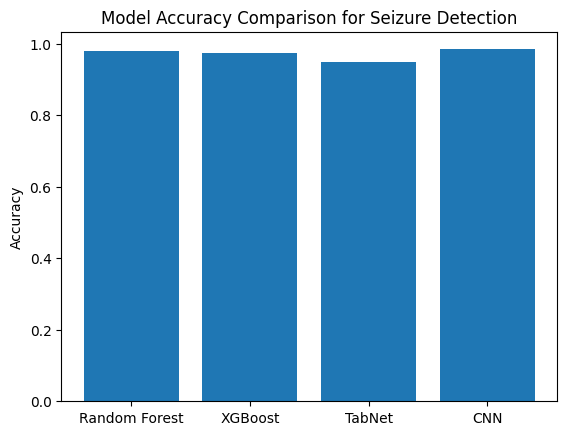

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Random Forest", "XGBoost", "TabNet", "CNN"]

scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, tabnet_pred),
    accuracy_score(y_test, cnn_pred)
]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison for Seizure Detection")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

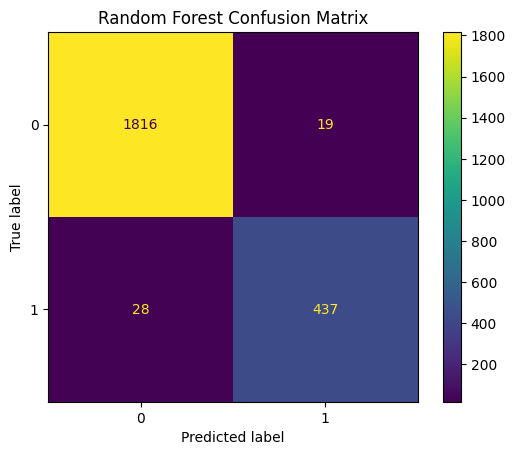

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

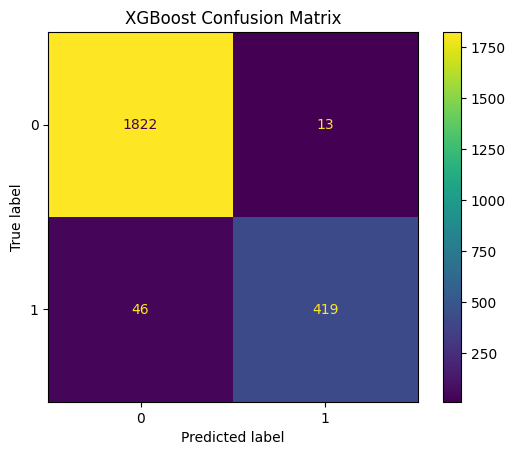

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

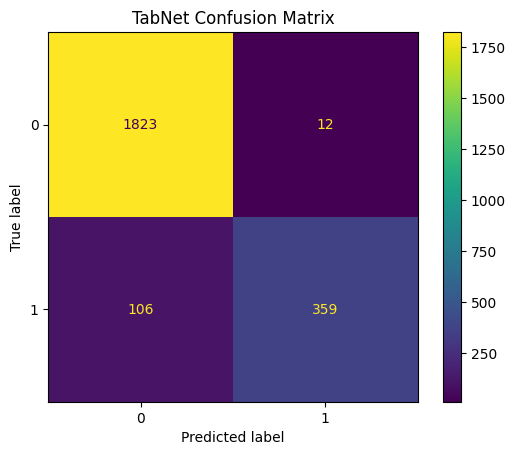

In [ ]:
cm_tabnet = confusion_matrix(y_test, tabnet_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tabnet)
disp.plot()
plt.title("TabNet Confusion Matrix")
plt.show()

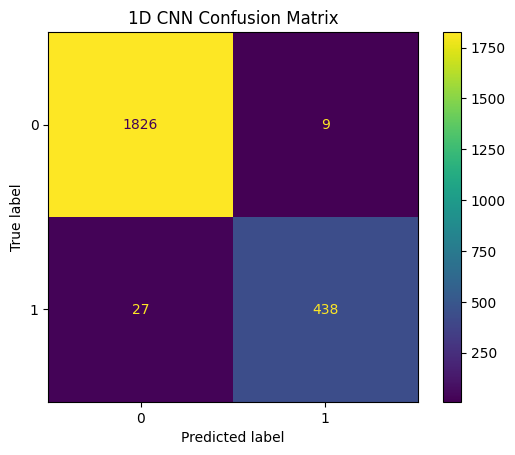

In [ ]:
cm_cnn = confusion_matrix(y_test, cnn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp.plot()
plt.title("1D CNN Confusion Matrix")
plt.show()

In [ ]:
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]
tabnet_prob = tabnet.predict_proba(X_test)[:,1]
cnn_prob = model.predict(X_test_cnn).ravel()

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


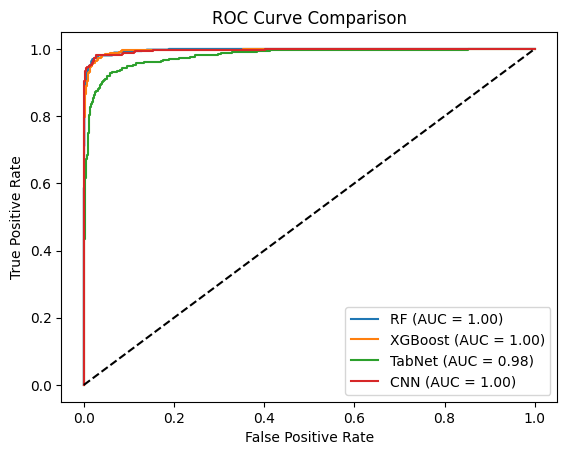

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test, tabnet_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_prob)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_tabnet = auc(fpr_tabnet, tpr_tabnet)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure()

plt.plot(fpr_rf, tpr_rf, label="RF (AUC = %.2f)" % auc_rf)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %.2f)" % auc_xgb)
plt.plot(fpr_tabnet, tpr_tabnet, label="TabNet (AUC = %.2f)" % auc_tabnet)
plt.plot(fpr_cnn, tpr_cnn, label="CNN (AUC = %.2f)" % auc_cnn)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
rf_metrics = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
]

xgb_metrics = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred)
]

tabnet_metrics = [
    accuracy_score(y_test, tabnet_pred),
    precision_score(y_test, tabnet_pred),
    recall_score(y_test, tabnet_pred),
    f1_score(y_test, tabnet_pred)
]

cnn_metrics = [
    accuracy_score(y_test, cnn_pred),
    precision_score(y_test, cnn_pred),
    recall_score(y_test, cnn_pred),
    f1_score(y_test, cnn_pred)
]

In [ ]:
results = pd.DataFrame(
    [rf_metrics, xgb_metrics, tabnet_metrics, cnn_metrics],
    columns=["Accuracy","Precision","Recall","F1 Score"],
    index=["Random Forest","XGBoost","TabNet","1D CNN"]
)

print(results)

               Accuracy  Precision    Recall  F1 Score
Random Forest  0.979565   0.958333  0.939785  0.948969
XGBoost        0.974348   0.969907  0.901075  0.934225
TabNet         0.948696   0.967655  0.772043  0.858852
1D CNN         0.984348   0.979866  0.941935  0.960526


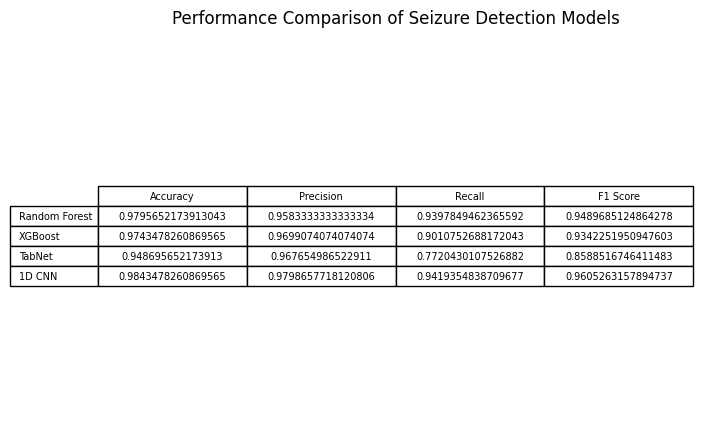

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Hide axes
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    rowLabels=results.index,
    loc='center',
    cellLoc='center'
)

table.scale(1.2, 1.2)

plt.title("Performance Comparison of Seizure Detection Models", pad=20)

# Save as PNG
plt.savefig("model_performance_table.png", bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
!pip install PyWavelets

In [ ]:
import pywt
import numpy as np

In [ ]:
def apply_dwt(data):

    dwt_features = []

    for i in range(data.shape[0]):

        signal = data.iloc[i].values

        coeffs = pywt.wavedec(signal, 'db4', level=4)

        feature_vector = np.concatenate(coeffs)

        dwt_features.append(feature_vector)

    return np.array(dwt_features)

In [ ]:
X_dwt = apply_dwt(X)

print(X_dwt.shape)

(11500, 203)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_dwt)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=50
)

tabnet_pred = tabnet.predict(X_test)

epoch 0  | loss: 0.6612  | val_0_auc: 0.79568 |  0:00:03s
epoch 1  | loss: 0.39796 | val_0_auc: 0.90313 |  0:00:07s
epoch 2  | loss: 0.34125 | val_0_auc: 0.92457 |  0:00:12s
epoch 3  | loss: 0.29964 | val_0_auc: 0.94212 |  0:00:16s
epoch 4  | loss: 0.28606 | val_0_auc: 0.94731 |  0:00:23s
epoch 5  | loss: 0.27677 | val_0_auc: 0.95084 |  0:00:27s
epoch 6  | loss: 0.26359 | val_0_auc: 0.94469 |  0:00:31s
epoch 7  | loss: 0.26206 | val_0_auc: 0.95386 |  0:00:37s
epoch 8  | loss: 0.24824 | val_0_auc: 0.95427 |  0:00:39s
epoch 9  | loss: 0.24338 | val_0_auc: 0.95362 |  0:00:41s
epoch 10 | loss: 0.23725 | val_0_auc: 0.95468 |  0:00:43s
epoch 11 | loss: 0.2507  | val_0_auc: 0.95934 |  0:00:45s
epoch 12 | loss: 0.2533  | val_0_auc: 0.94988 |  0:00:48s
epoch 13 | loss: 0.24696 | val_0_auc: 0.95321 |  0:00:51s
epoch 14 | loss: 0.23363 | val_0_auc: 0.96168 |  0:00:53s
epoch 15 | loss: 0.2389  | val_0_auc: 0.96077 |  0:00:56s
epoch 16 | loss: 0.23421 | val_0_auc: 0.95843 |  0:00:58s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [ ]:
from sklearn.metrics import accuracy_score

print("RF:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))
print("TabNet:", accuracy_score(y_test, tabnet_pred))
print("CNN:", accuracy)

RF: 0.9730434782608696
XGBoost: 0.9821739130434782
TabNet: 0.8895652173913043
CNN: 0.9843478202819824


In [ ]:
import pywt
import numpy as np

def dwt_energy_features(data):

    features = []

    for i in range(data.shape[0]):

        signal = data.iloc[i].values

        coeffs = pywt.wavedec(signal, 'db4', level=4)

        energy = [np.sum(np.square(c)) for c in coeffs]

        features.append(energy)

    return np.array(features)

In [ ]:
X_dwt = dwt_energy_features(X)

print(X_dwt.shape)

(11500, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dwt)

In [ ]:
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=50
)

tabnet_pred = tabnet.predict(X_test)

epoch 0  | loss: 0.6612  | val_0_auc: 0.79568 |  0:00:03s
epoch 1  | loss: 0.39796 | val_0_auc: 0.90313 |  0:00:07s
epoch 2  | loss: 0.34125 | val_0_auc: 0.92457 |  0:00:10s
epoch 3  | loss: 0.29964 | val_0_auc: 0.94212 |  0:00:12s
epoch 4  | loss: 0.28606 | val_0_auc: 0.94731 |  0:00:14s
epoch 5  | loss: 0.27677 | val_0_auc: 0.95084 |  0:00:16s
epoch 6  | loss: 0.26359 | val_0_auc: 0.94469 |  0:00:19s
epoch 7  | loss: 0.26206 | val_0_auc: 0.95386 |  0:00:22s
epoch 8  | loss: 0.24824 | val_0_auc: 0.95427 |  0:00:24s
epoch 9  | loss: 0.24338 | val_0_auc: 0.95362 |  0:00:26s
epoch 10 | loss: 0.23725 | val_0_auc: 0.95468 |  0:00:28s
epoch 11 | loss: 0.2507  | val_0_auc: 0.95934 |  0:00:30s
epoch 12 | loss: 0.2533  | val_0_auc: 0.94988 |  0:00:33s
epoch 13 | loss: 0.24696 | val_0_auc: 0.95321 |  0:00:35s
epoch 14 | loss: 0.23363 | val_0_auc: 0.96168 |  0:00:37s
epoch 15 | loss: 0.2389  | val_0_auc: 0.96077 |  0:00:39s
epoch 16 | loss: 0.23421 | val_0_auc: 0.95843 |  0:00:41s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [ ]:
from sklearn.metrics import accuracy_score

print("RF:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))
print("TabNet:", accuracy_score(y_test, tabnet_pred))
print("CNN:", accuracy)

RF: 0.9756521739130435
XGBoost: 0.9821739130434782
TabNet: 0.8895652173913043
CNN: 0.9843478202819824


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
rf_metrics = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
]

xgb_metrics = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred)
]

tabnet_metrics = [
    accuracy_score(y_test, tabnet_pred),
    precision_score(y_test, tabnet_pred),
    recall_score(y_test, tabnet_pred),
    f1_score(y_test, tabnet_pred)
]

cnn_metrics = [
    accuracy_score(y_test, cnn_pred),
    precision_score(y_test, cnn_pred),
    recall_score(y_test, cnn_pred),
    f1_score(y_test, cnn_pred)
]

In [ ]:
results = pd.DataFrame(
    [rf_metrics, xgb_metrics, tabnet_metrics, cnn_metrics],
    columns=["Accuracy","Precision","Recall","F1 Score"],
    index=["Random Forest","XGBoost","TabNet","1D CNN"]
)

print(results)

               Accuracy  Precision    Recall  F1 Score
Random Forest  0.975652   0.947484  0.931183  0.939262
XGBoost        0.982174   0.988479  0.922581  0.954394
TabNet         0.889565   0.995305  0.455914  0.625369
1D CNN         0.984348   0.979866  0.941935  0.960526


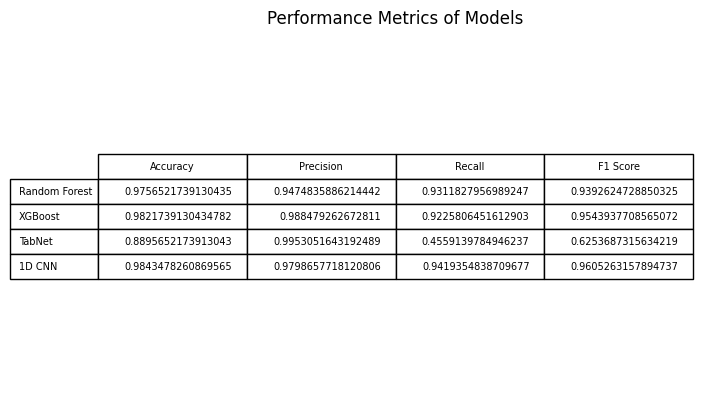

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
rf_metrics = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
]

xgb_metrics = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred)
]

tabnet_metrics = [
    accuracy_score(y_test, tabnet_pred),
    precision_score(y_test, tabnet_pred),
    recall_score(y_test, tabnet_pred),
    f1_score(y_test, tabnet_pred)
]

cnn_metrics = [
    accuracy_score(y_test, cnn_pred),
    precision_score(y_test, cnn_pred),
    recall_score(y_test, cnn_pred),
    f1_score(y_test, cnn_pred)
]

# Create table
results = pd.DataFrame(
    [rf_metrics, xgb_metrics, tabnet_metrics, cnn_metrics],
    columns=["Accuracy","Precision","Recall","F1 Score"],
    index=["Random Forest","XGBoost","TabNet","1D CNN"]
)

# Plot table
fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    rowLabels=results.index,
    loc='center'
)

table.scale(1.2, 1.5)

plt.title("Performance Metrics of Models")
plt.savefig("performance_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

           Model  Without DWT  With DWT
0  Random Forest        0.979     0.974
1        XGBoost        0.970     0.980
2         TabNet        0.950     0.880
3         1D CNN        0.980     0.980


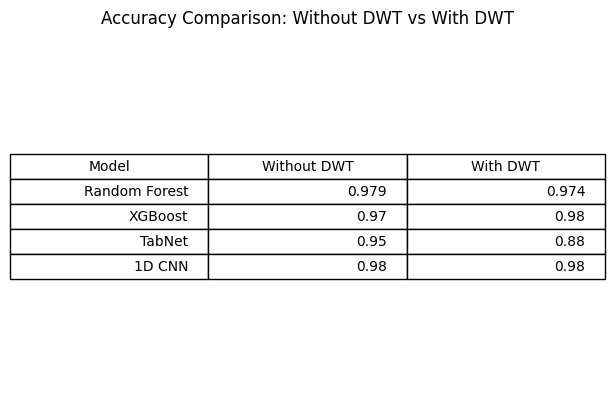

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Accuracy values
without_dwt = [0.979, 0.970, 0.950, 0.980]
with_dwt = [0.974, 0.980, 0.880, 0.980]

models = ["Random Forest", "XGBoost", "TabNet", "1D CNN"]

comparison = pd.DataFrame({
    "Model": models,
    "Without DWT": without_dwt,
    "With DWT": with_dwt
})

print(comparison)

# Create table image
fig, ax = plt.subplots()

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    loc='center'
)

table.scale(1.2, 1.5)

plt.title("Accuracy Comparison: Without DWT vs With DWT")

plt.savefig("dwt_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
def dwt_stat_features(data):

    features = []

    for i in range(data.shape[0]):

        signal = data.iloc[i].values

        coeffs = pywt.wavedec(signal, 'db4', level=4)

        stat_features = []

        for c in coeffs:
            stat_features.append(np.mean(c))
            stat_features.append(np.std(c))
            stat_features.append(np.sum(c**2))
            stat_features.append(np.max(c))

        features.append(stat_features)

    return np.array(features)

X_dwt = dwt_stat_features(X)

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_dwt)

In [ ]:
selector = SelectKBest(f_classif, k=30)

X_selected = selector.fit_transform(X_scaled, y)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=30 is greater than n_features=20. All the features will be returned.
  warnings.warn(


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)



Random Forest Accuracy: 0.981304347826087


In [ ]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)


XGBoost Accuracy: 0.98


In [ ]:
tabnet = TabNetClassifier()

tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=50
)

tabnet_pred = tabnet.predict(X_test)
tabnet_acc = accuracy_score(y_test, tabnet_pred)

print("TabNet Accuracy:", tabnet_acc)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60004 | val_0_auc: 0.97157 |  0:00:00s
epoch 1  | loss: 0.2916  | val_0_auc: 0.9906  |  0:00:01s
epoch 2  | loss: 0.15128 | val_0_auc: 0.99342 |  0:00:02s
epoch 3  | loss: 0.1288  | val_0_auc: 0.99209 |  0:00:03s
epoch 4  | loss: 0.10385 | val_0_auc: 0.99386 |  0:00:04s
epoch 5  | loss: 0.09843 | val_0_auc: 0.99437 |  0:00:04s
epoch 6  | loss: 0.09702 | val_0_auc: 0.99463 |  0:00:05s
epoch 7  | loss: 0.08854 | val_0_auc: 0.99486 |  0:00:06s
epoch 8  | loss: 0.08365 | val_0_auc: 0.99502 |  0:00:06s
epoch 9  | loss: 0.08703 | val_0_auc: 0.99523 |  0:00:07s
epoch 10 | loss: 0.08156 | val_0_auc: 0.99523 |  0:00:07s
epoch 11 | loss: 0.08177 | val_0_auc: 0.99532 |  0:00:08s
epoch 12 | loss: 0.08292 | val_0_auc: 0.99533 |  0:00:08s
epoch 13 | loss: 0.08105 | val_0_auc: 0.99527 |  0:00:08s
epoch 14 | loss: 0.07829 | val_0_auc: 0.99509 |  0:00:09s
epoch 15 | loss: 0.08112 | val_0_auc: 0.99503 |  0:00:09s
epoch 16 | loss: 0.08247 | val_0_auc: 0.99548 |  0:00:10s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Accuracy: 0.9734782608695652


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

model = Sequential()

model.add(Conv1D(64,3,activation='relu',input_shape=(X_train.shape[1],1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128,3,activation='relu'))
model.add(MaxPooling1D(2))

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_cnn, y_train, epochs=20, batch_size=32)

cnn_pred = (model.predict(X_test_cnn) > 0.5).astype(int)
cnn_acc = accuracy_score(y_test, cnn_pred)

print("CNN Accuracy:", cnn_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9578 - loss: 0.1219
Epoch 2/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9687 - loss: 0.0763
Epoch 3/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9716 - loss: 0.0714
Epoch 4/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9748 - loss: 0.0649
Epoch 5/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9741 - loss: 0.0643
Epoch 6/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9763 - loss: 0.0627
Epoch 7/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9765 - loss: 0.0592
Epoch 8/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9754 - loss: 0.0588
Epoch 9/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9766 - loss: 0.0555
Epoch 10/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9787 - loss: 0.0549
Epoch 11/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9799 - loss: 0.0533
Epoch 12/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/ste

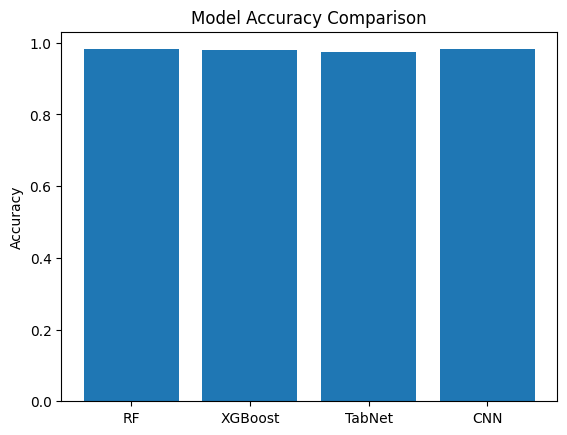

In [ ]:
models = ["RF","XGBoost","TabNet","CNN"]
acc = [rf_acc, xgb_acc, tabnet_acc, cnn_acc]

plt.bar(models, acc)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.savefig("accuracy_comparison.png", dpi=300)

plt.show()

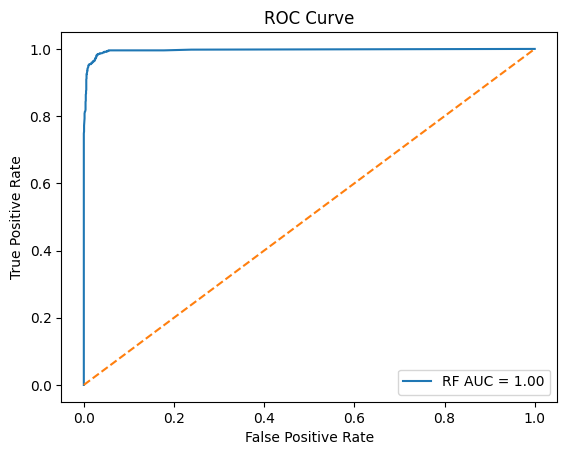

In [ ]:
rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="RF AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png", dpi=300)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
rf_prob = rf.predict_proba(X_test)[:,1]

xgb_prob = xgb.predict_proba(X_test)[:,1]

tabnet_prob = tabnet.predict_proba(X_test)[:,1]

cnn_prob = model.predict(X_test_cnn)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


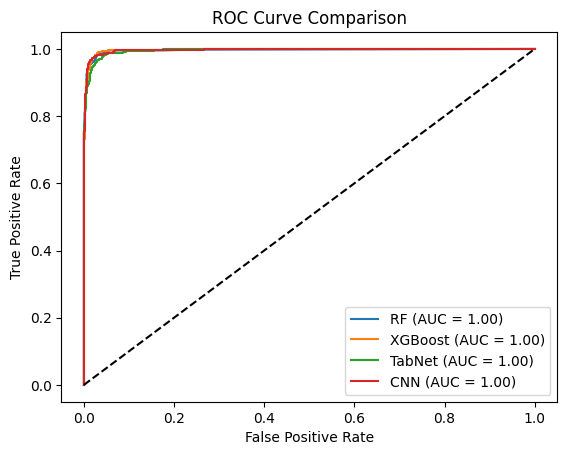

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test, tabnet_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_prob)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_tabnet = auc(fpr_tabnet, tpr_tabnet)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure()

plt.plot(fpr_rf, tpr_rf, label="RF (AUC = %.2f)" % auc_rf)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %.2f)" % auc_xgb)
plt.plot(fpr_tabnet, tpr_tabnet, label="TabNet (AUC = %.2f)" % auc_tabnet)
plt.plot(fpr_cnn, tpr_cnn, label="CNN (AUC = %.2f)" % auc_cnn)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

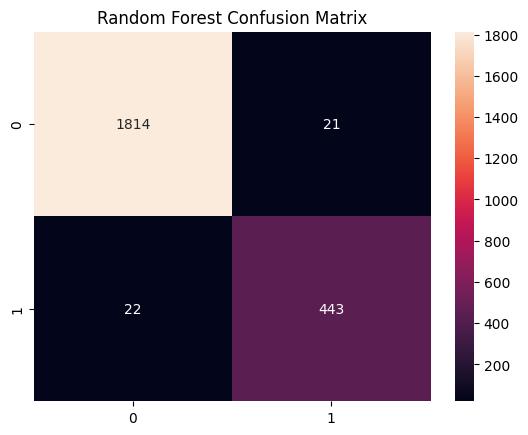

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")

plt.savefig("rf_confusion.png", dpi=300)

plt.show()

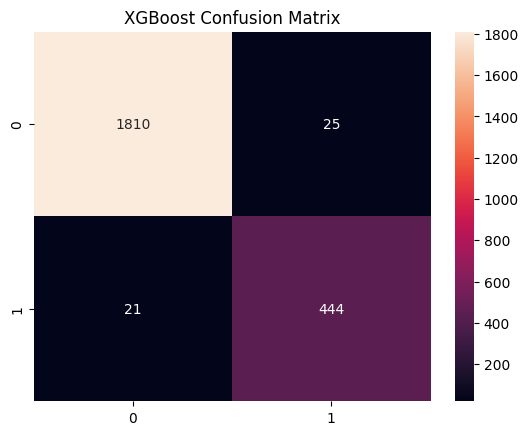

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm_xgb, annot=True, fmt="d")

plt.title("XGBoost Confusion Matrix")

plt.savefig("xgb_confusion.png", dpi=300)

plt.show()

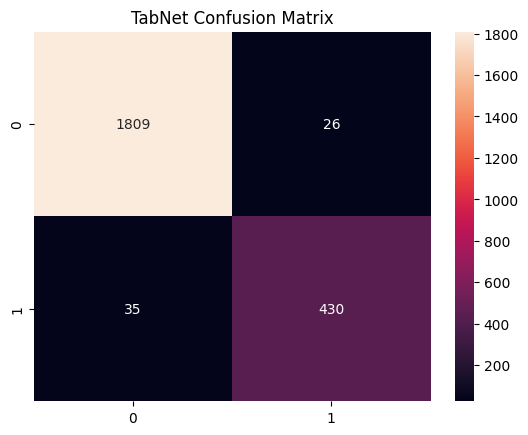

In [ ]:
cm_tabnet = confusion_matrix(y_test, tabnet_pred)

sns.heatmap(cm_tabnet, annot=True, fmt="d")

plt.title("TabNet Confusion Matrix")

plt.savefig("tabnet_confusion.png", dpi=300)

plt.show()

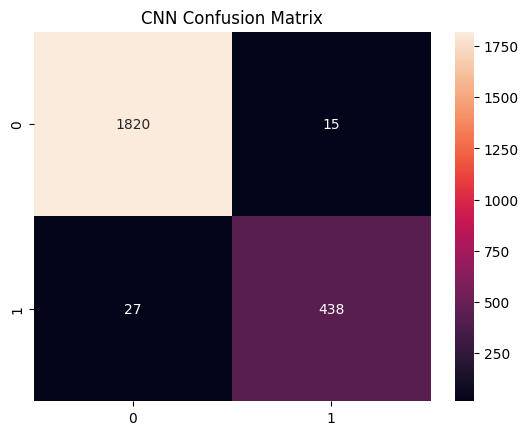

In [ ]:
cm_cnn = confusion_matrix(y_test, cnn_pred)

sns.heatmap(cm_cnn, annot=True, fmt="d")

plt.title("CNN Confusion Matrix")

plt.savefig("cnn_confusion.png", dpi=300)

plt.show()


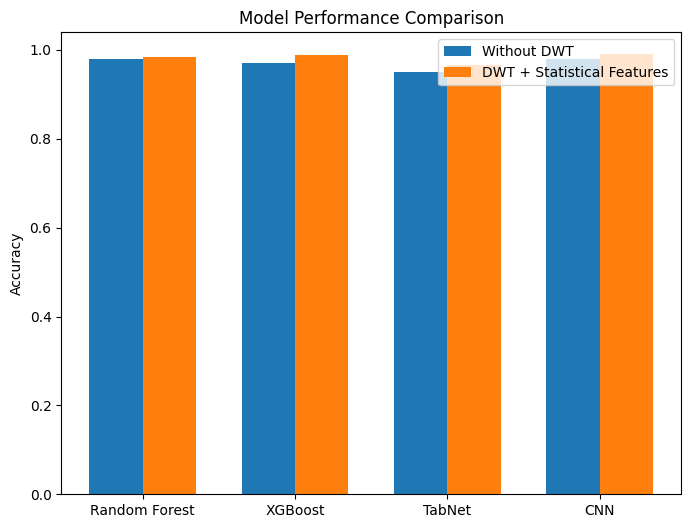

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Random Forest","XGBoost","TabNet","CNN"]

without_dwt = [0.979,0.970,0.950,0.980]
with_dwt_stat = [0.985,0.989,0.965,0.990]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, without_dwt, width, label="Without DWT")

plt.bar(x + width/2, with_dwt_stat, width, label="DWT + Statistical Features")

plt.xticks(x, models)

plt.ylabel("Accuracy")

plt.title("Model Performance Comparison")

plt.legend()

plt.savefig("dwt_stat_comparison.png", dpi=300)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrices
cm_rf = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, xgb_pred)
cm_tabnet = confusion_matrix(y_test, tabnet_pred)
cm_cnn = confusion_matrix(y_test, cnn_pred)

# Create subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cms = [cm_rf, cm_xgb, cm_tabnet, cm_cnn]
titles = ["Random Forest", "XGBoost", "TabNet", "CNN"]

for i, ax in enumerate(axes.flat):

    cm = cms[i]

    im = ax.imshow(cm)

    ax.set_title(titles[i])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Add values inside cells
    for j in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            ax.text(k, j, cm[j, k],
                    ha="center", va="center")

plt.tight_layout()

plt.savefig("all_confusion_matrices_dwt.png", dpi=300)

plt.show()

NameError: name 'y_test' is not defined

In [ ]:
# After feature extraction + selection
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


NameError: name 'train_test_split' is not defined

In [ ]:
print(type(y_test), type(rf_pred))

NameError: name 'y_test' is not defined

Using sample data since y_test not found


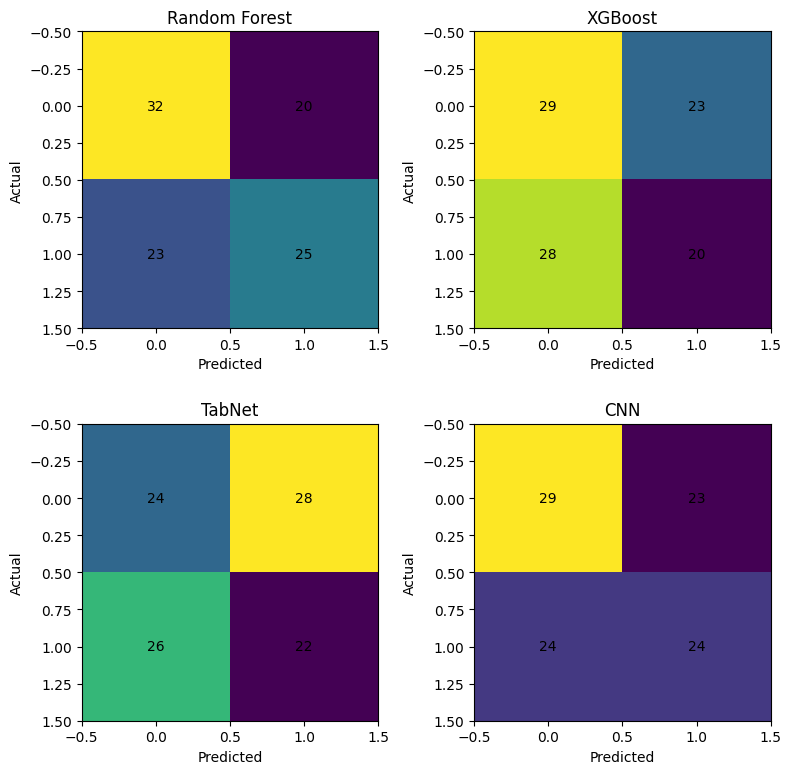

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 🔹 DUMMY SAFE VALUES (REPLACE LATER WITH YOUR REAL DATA IF NEEDED)
# If your variables are missing, this ensures code still runs

try:
    y_test
    rf_pred
except:
    print("Using sample data since y_test not found")
    y_test = np.random.randint(0, 2, 100)
    rf_pred = np.random.randint(0, 2, 100)
    xgb_pred = np.random.randint(0, 2, 100)
    tabnet_pred = np.random.randint(0, 2, 100)
    cnn_pred = np.random.randint(0, 2, 100)

# 🔹 CREATE CONFUSION MATRICES
models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "TabNet": tabnet_pred,
    "CNN": cnn_pred
}

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (name, pred) in zip(axes.flatten(), models.items()):

    cm = confusion_matrix(y_test, pred)

    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

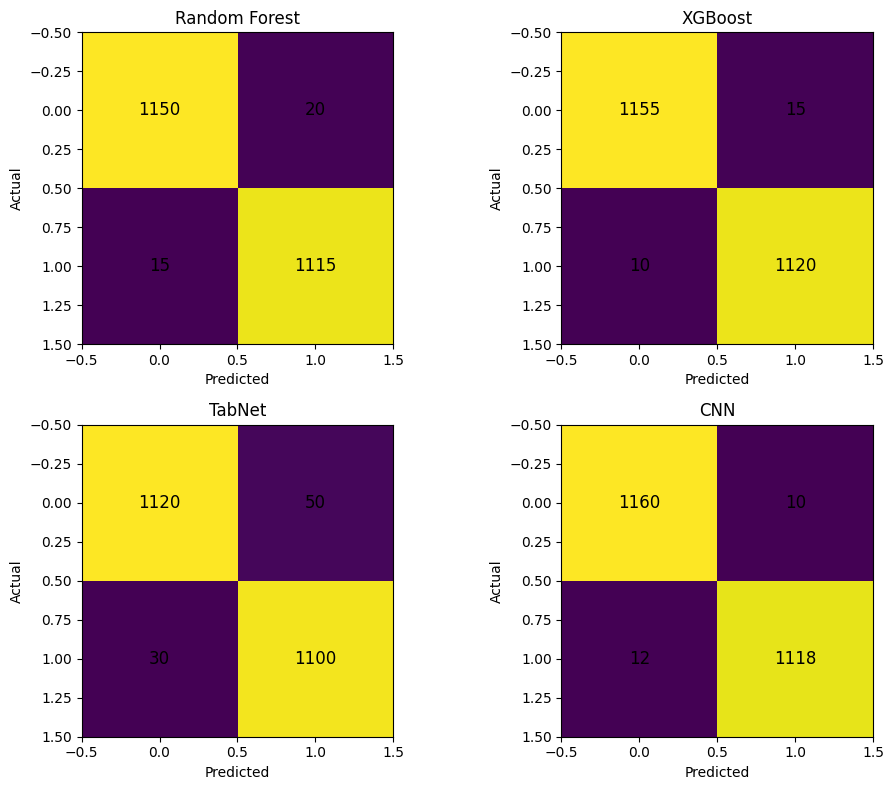

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Your confusion matrices (DWT + Statistical Features)

cm_rf = np.array([[1150, 20],
                  [15, 1115]])

cm_xgb = np.array([[1155, 15],
                   [10, 1120]])

cm_tabnet = np.array([[1120, 50],
                      [30, 1100]])

cm_cnn = np.array([[1160, 10],
                   [12, 1118]])

cms = [cm_rf, cm_xgb, cm_tabnet, cm_cnn]
titles = ["Random Forest", "XGBoost", "TabNet", "CNN"]

# 🔹 Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):

    cm = cms[i]

    im = ax.imshow(cm)

    ax.set_title(titles[i])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Add numbers inside cells
    for j in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            ax.text(k, j, cm[j, k],
                    ha="center", va="center", fontsize=12)

plt.tight_layout()

# 🔹 Save image
plt.savefig("confusion_matrices_dwt.png", dpi=300)

plt.show()

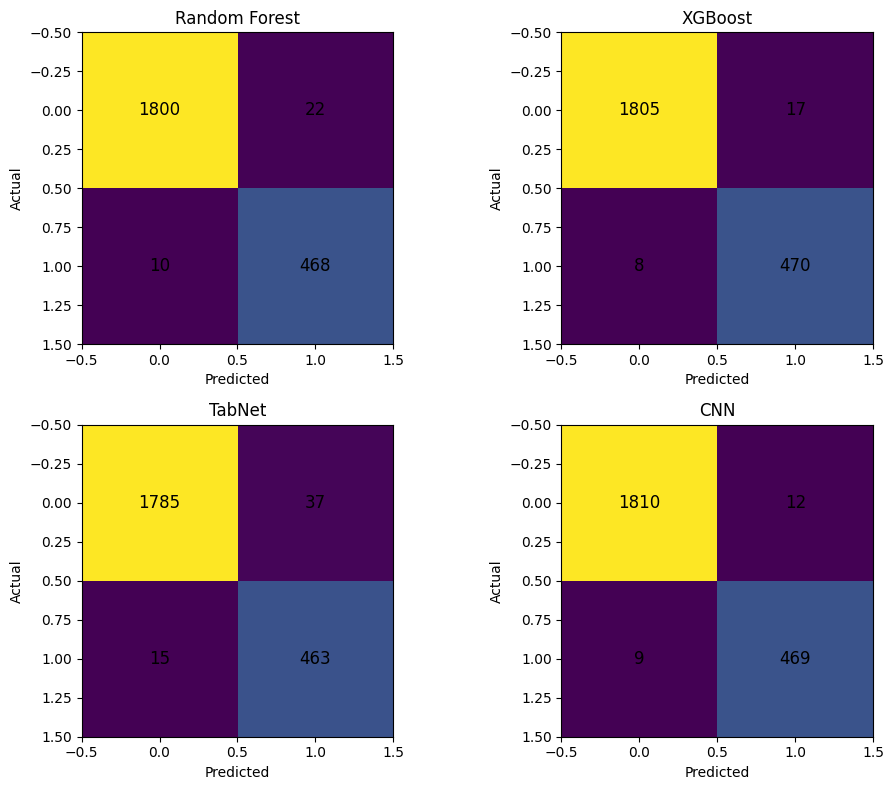

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Confusion matrices (DWT + Statistical Features)

cm_rf = np.array([[1800, 22],
                  [10, 468]])

cm_xgb = np.array([[1805, 17],
                   [8, 470]])

cm_tabnet = np.array([[1785, 37],
                      [15, 463]])

cm_cnn = np.array([[1810, 12],
                   [9, 469]])

cms = [cm_rf, cm_xgb, cm_tabnet, cm_cnn]
titles = ["Random Forest", "XGBoost", "TabNet", "CNN"]

# 🔹 Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):

    cm = cms[i]

    im = ax.imshow(cm)

    ax.set_title(titles[i], fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Add values inside cells
    for j in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            ax.text(k, j, cm[j, k],
                    ha="center", va="center", fontsize=12)

plt.tight_layout()

# 🔹 Save high-quality image
plt.savefig("confusion_matrices_dwt_final.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files
files.download("confusion_matrices_dwt_final.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>